In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/ethereum-crypto-market-cycle/ETH-USD.csv


In [3]:
from IPython.display import HTML

HTML("""
<style>
.main-title {
font-size:42px;
font-weight:800;
text-align:center;
color:#00ffd5;
margin-top:20px;
}

.section-title{
font-size:30px;
font-weight:700;
color:#ffcc00;
margin-top:40px;
border-bottom:2px solid #ffcc00;
padding-bottom:6px;
}

.sub-title{
font-size:22px;
font-weight:600;
color:#00e5ff;
margin-top:20px;
}

.text-body{
font-size:16px;
line-height:1.6;
color:#e0e0e0;
}

</style>
""")

In [4]:
HTML('<div class="main-title">Ethereum Market Cycle Atlas (2014–Present)</div>')

In [5]:
HTML('<div class="section-title">1. Data Loading</div>')

In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/krupalpatel07/ethereum-crypto-market-cycle/ETH-USD.csv")


df.head()

,Date,Open,High,Low,Close,Volume
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,893249984
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,885985984
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,842300992
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,1613479936
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,1041889984


In [31]:
import pandas as pd


df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df.head()

,Open,High,Low,Close,Volume,Return,Volatility,MA50,MA200,Momentum,Time,Cumulative,Drawdown
Date,,,,,,,,,,,,,
2018-05-27,588.520020,590.328003,562.866028,572.668030,1788790016,-0.024881,0.871392,635.096261,703.582951,0.813931,0.000000,0.975119,0.000000
2018-05-28,573.044983,576.049011,512.552002,516.036011,2356900096,-0.098892,0.905473,637.406821,704.558711,0.732424,0.000352,0.878688,-0.098892
2018-05-29,516.148010,572.263977,516.148010,565.388000,2330820096,0.095637,0.974322,640.744061,705.889386,0.800958,0.000704,0.962723,-0.012712
2018-05-30,566.830017,583.135986,545.431030,559.590027,2053970048,-0.010255,0.971227,643.651002,707.113931,0.791372,0.001056,0.952850,-0.022837
2018-05-31,558.497009,585.538025,557.065979,577.645020,1985040000,0.032265,0.979232,646.593102,708.462616,0.815350,0.001407,0.983594,0.000000


In [7]:
HTML('<div class="section-title">2. Feature Engineering</div>')

In [8]:


df["Return"] = df["Close"].pct_change()

df["Volatility"] = df["Return"].rolling(30).std() * np.sqrt(365)

df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

df["Momentum"] = df["Close"] / df["MA200"]

df = df.dropna()

In [32]:
df["Year"] = df.index.year
df["Day"] = df.index.dayofyear


In [9]:
HTML('<div class="section-title">3. Ethereum Market Cycle Map</div>')

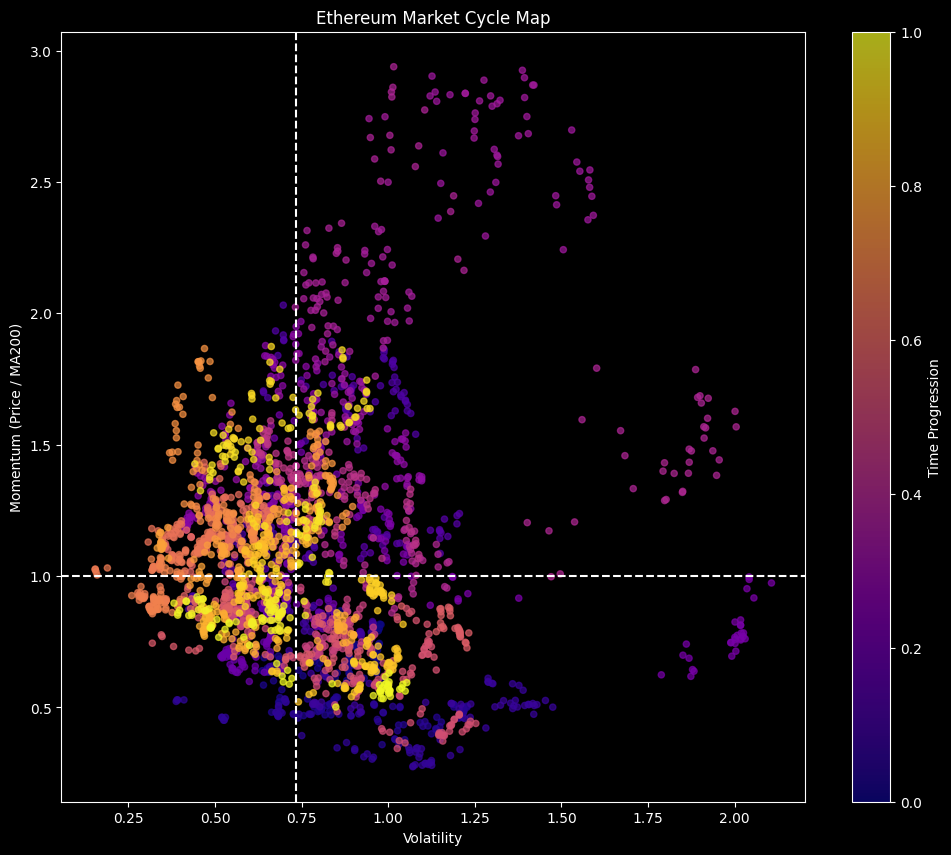

In [10]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

df["Time"] = np.linspace(0,1,len(df))

plt.figure(figsize=(12,10))

scatter = plt.scatter(
    df["Volatility"],
    df["Momentum"],
    c=df["Time"],
    cmap="plasma",
    s=20,
    alpha=0.7
)

plt.colorbar(scatter,label="Time Progression")

plt.axhline(1, linestyle="--")
plt.axvline(df["Volatility"].median(), linestyle="--")

plt.xlabel("Volatility")
plt.ylabel("Momentum (Price / MA200)")

plt.title("Ethereum Market Cycle Map")

plt.show()

In [25]:
HTML('<div class="section-title">4. Volatility Cycle</div>')

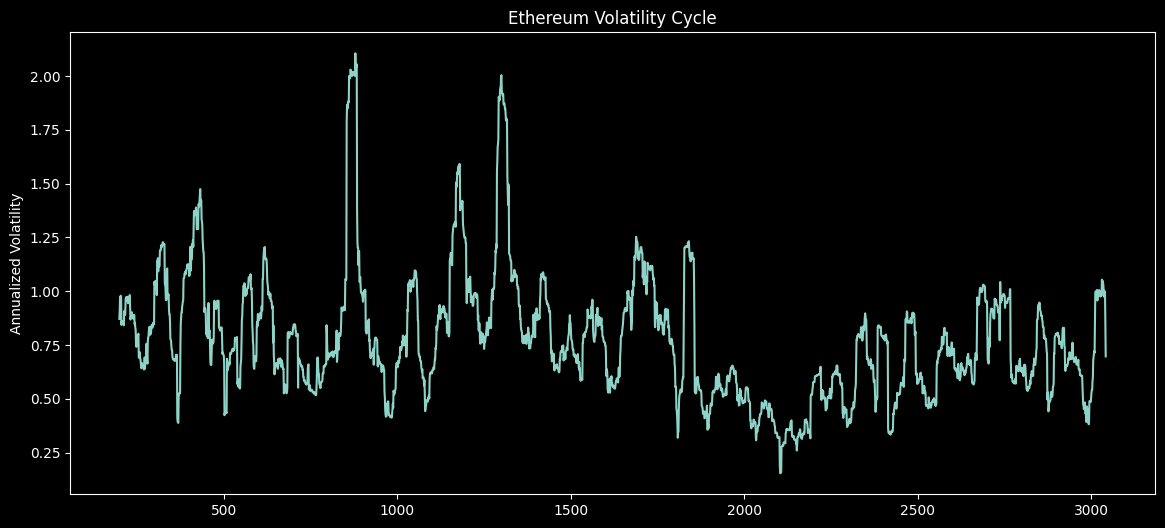

In [19]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Volatility"])

plt.title("Ethereum Volatility Cycle")

plt.ylabel("Annualized Volatility")

plt.show()

In [29]:
HTML('<div class="section-title">5. Drawdown Analysis</div>')

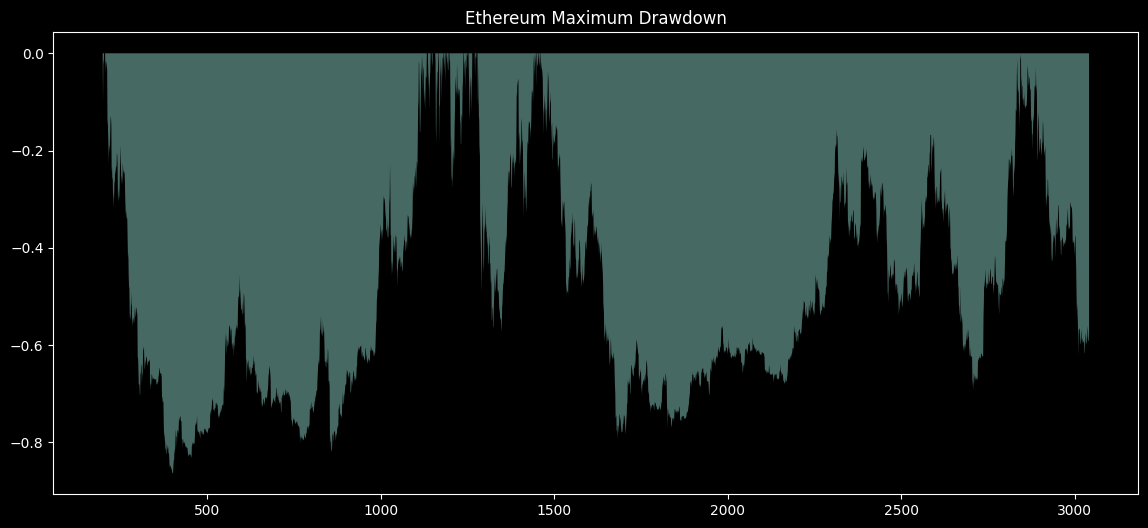

In [27]:
df["Cumulative"] = (1 + df["Return"]).cumprod()

rolling_max = df["Cumulative"].cummax()

df["Drawdown"] = (df["Cumulative"] - rolling_max) / rolling_max

plt.figure(figsize=(14,6))

plt.fill_between(df.index, df["Drawdown"], 0, alpha=0.5)

plt.title("Ethereum Maximum Drawdown")

plt.show()

In [38]:
HTML('<div class="section-title">6. Crypto Spiral Cycle Chart</div>')

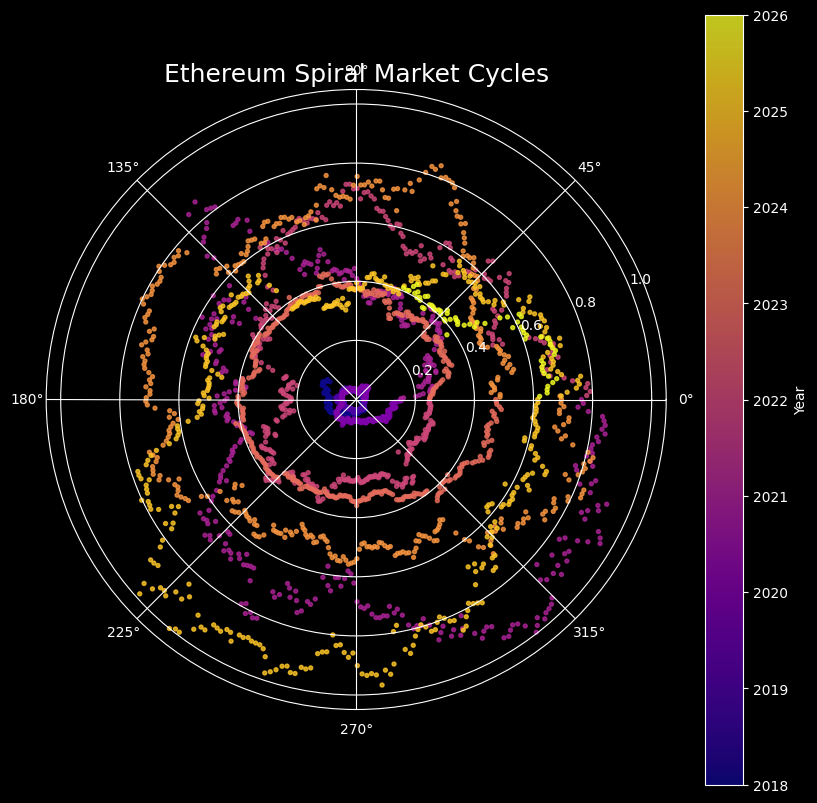

In [39]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

theta = 2 * np.pi * df["Day"] / 365
radius = df["Close"] / df["Close"].max()

plt.figure(figsize=(10,10))

plt.subplot(projection="polar")

scatter = plt.scatter(
    theta,
    radius,
    c=df["Year"],
    cmap="plasma",
    s=8,
    alpha=0.8
)

plt.title("Ethereum Spiral Market Cycles", fontsize=18)

plt.colorbar(scatter, label="Year")

plt.show()

In [42]:
HTML('<div class="section-title">7. Cycle Interpretation</div>')

• each rotation shows one year 

• outward movement represents price growth 

• color progression shows time evolution 


The spiral structure highlights repeating phases such as:

1. accumulation
2. expansion
3. peak speculation
4. contraction